# Visualize U-Net predictions

This notebook loads a released model bundle and demonstrates the reusable map panels in `mindthegap.viz`. Evaluation over many dates belongs in `4-U-Net_Evaluation.ipynb`.

In [1]:
from pathlib import Path
import sys

for parent in (Path.cwd(), Path.cwd().parent):
    if (parent / "mindthegap").is_dir():
        sys.path.insert(0, str(parent))
        break

import matplotlib.pyplot as plt
import mindthegap as mtg
from mindthegap import viz

## Load a model bundle

Use a local bundle directory or a Hugging Face repository ID. The metadata supplies the exact channel order and standardization needed for prediction.

In [2]:
bundle_source = "../models/io-shared-public-unet-bundle"

if Path(bundle_source).is_dir():
    bundle_path = Path(bundle_source)
else:
    from huggingface_hub import snapshot_download
    bundle_path = Path(snapshot_download(repo_id=bundle_source))

model, metadata = mtg.load_model_bundle(bundle_path)
input_vars = [item["name"] for item in metadata["inputs"]]
print(f"Loaded: {metadata['model']['name']}")
print(f"Inputs: {input_vars}")

2026-08-09 04:09:36.888860: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-09 04:09:36.902980: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1786248576.921530   10532 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1786248576.927924   10532 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1786248576.942111   10532 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Loaded: IO rechunkded in shared-public U-Net gap filler
Inputs: ['masked_target', 'masked_target_m1', 'masked_target_p1', 'day_sin', 'day_cos', 'synthetic_missing_flag', 'true_missing_flag', 'valid_masked_target_flag', 'land_flag']


## Prepare matching data

The example below reconstructs the deterministic demo data used by `2-U-Net_Fit_Generic.ipynb`. For another bundle, replace this cell with the matching dataset loader and preprocessing recorded in `model_metadata.yaml`.

In [3]:
# Reconstruct the exact inputs the bundle was trained on, driven entirely by
# the recorded metadata (options.data). This loads the same product, region,
# variable names, log-transform, and temporal lags used during training.
data_cfg = metadata["options"]["data"]

ds, _ = mtg.demo_data(
    dataset="io-shared-public",
    region=data_cfg.get("region_name"),
    time_slice=slice(*metadata["dataset"]["training_period"].split(" to ")),
)
ds = mtg.crop_to_multiple(ds, multiple=8)

train_end = metadata["dataset"]["training_period"].split(" to ")[1]
standardized_vars = [
    name
    for name, values in data_cfg["standardization"].items()
    if values.get("applied")
]

ds_std, _ = mtg.build_standardized_lazy(
    ds,
    target_variable=data_cfg["target_variable"],
    missing_flag=data_cfg["missing_flag"],
    land_flag=data_cfg["land_flag"],
    train_dates=slice(str(ds.time.values[0])[:10], train_end),
    std_vars=standardized_vars or None,
    log_target=data_cfg["log_target"],
    missing_flag_shift=10,
    n_temporal_lags=data_cfg["n_temporal_lags"],
    add_geo=data_cfg["add_geo"],
)

missing_inputs = [name for name in input_vars if name not in ds_std]
if missing_inputs:
    raise ValueError(f"Prepared dataset is missing bundle inputs: {missing_inputs}")
ds_std

<xarray.Dataset> Size: 412MB
Dimensions:                   (time: 365, lat: 168, lon: 240)
Coordinates:
  * time                      (time) datetime64[ns] 3kB 2000-01-01 ... 2000-1...
  * lat                       (lat) float32 672B 30.0 29.75 ... -11.5 -11.75
  * lon                       (lon) float32 960B 42.0 42.25 42.5 ... 101.5 101.8
Data variables:
    full_target               (time, lat, lon) float32 59MB dask.array<chunksize=(100, 168, 240), meta=np.ndarray>
    masked_target             (time, lat, lon) float32 59MB dask.array<chunksize=(100, 168, 240), meta=np.ndarray>
    masked_target_m1          (time, lat, lon) float32 59MB dask.array<chunksize=(100, 168, 240), meta=np.ndarray>
    masked_target_p1          (time, lat, lon) float32 59MB dask.array<chunksize=(100, 168, 240), meta=np.ndarray>
    day_sin                   (time, lat, lon) float32 59MB dask.array<chunksize=(100, 168, 240), meta=np.ndarray>
    day_cos                   (time, lat, lon) float32 59MB dask.array<chunksize=(100, 168, 240), meta=np.ndarray>
    synthetic_missing_flag    (time, lat, lon) int8 15MB dask.array<chunksize=(100, 168, 240), meta=np.ndarray>
    true_missing_flag         (time, lat, lon) int8 15MB dask.array<chunksize=(100, 168, 240), meta=np.ndarray>
    valid_masked_target_flag  (time, lat, lon) int8 15MB dask.array<chunksize=(100, 168, 240), meta=np.ndarray>
    land_flag                 (time, lat, lon) int8 15MB dask.array<chunksize=(100, 168, 240), meta=np.ndarray>
Attributes: (12/92)
    Conventions:                     CF-1.8, ACDD-1.3
    DPM_reference:                   GC-UD-ACRI-PUG
    IODD_reference:                  GC-UD-ACRI-PUG
    acknowledgement:                 The Licensees will ensure that original ...
    citation:                        The Licensees will ensure that original ...
    cmems_product_id:                OCEANCOLOUR_GLO_BGC_L3_MY_009_103
    ...                              ...
    time_coverage_end:               2024-04-18T02:58:23Z
    time_coverage_resolution:        P1D
    time_coverage_start:             2024-04-16T21:12:05Z
    title:                           cmems_obs-oc_glo_bgc-plankton_my_l3-mult...
    westernmost_longitude:           -180.0
    westernmost_valid_longitude:     -180.0

## Individual panels

Each panel is available independently, so custom layouts do not duplicate plotting or prediction logic.

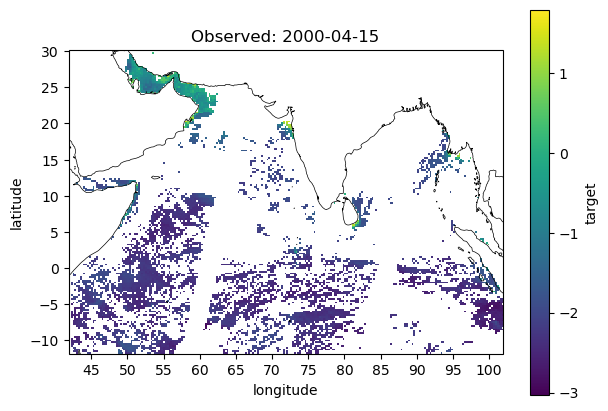

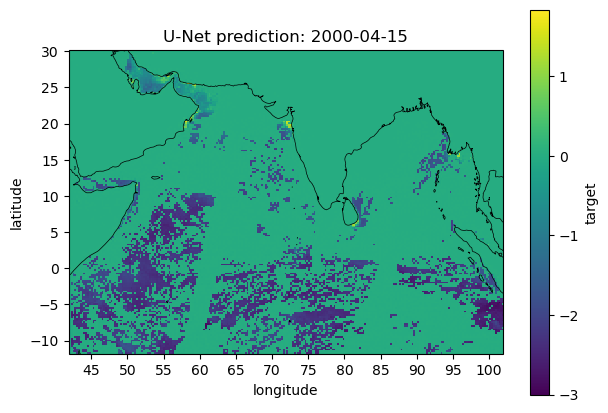

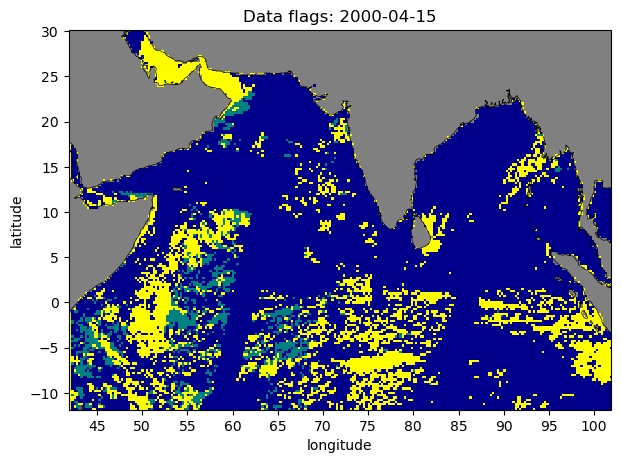

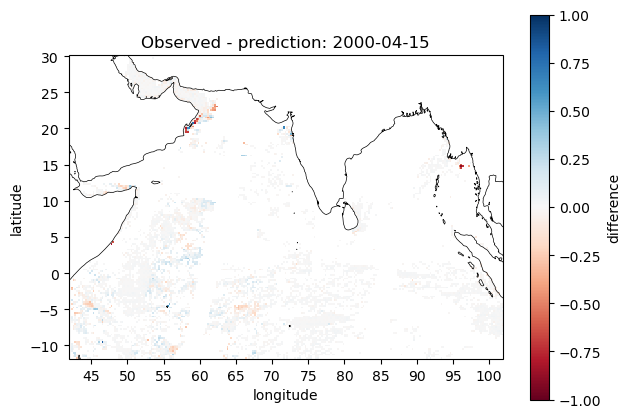

In [4]:
date = "2000-04-15"

viz.plot_observed(ds_std, metadata, date)
viz.plot_prediction(ds_std, model, metadata, date)
viz.plot_flags(ds_std, date)
viz.plot_difference(ds_std, model, metadata, date)

## Standard four-panel view

The composite calls the same individual panel functions and predicts only once.

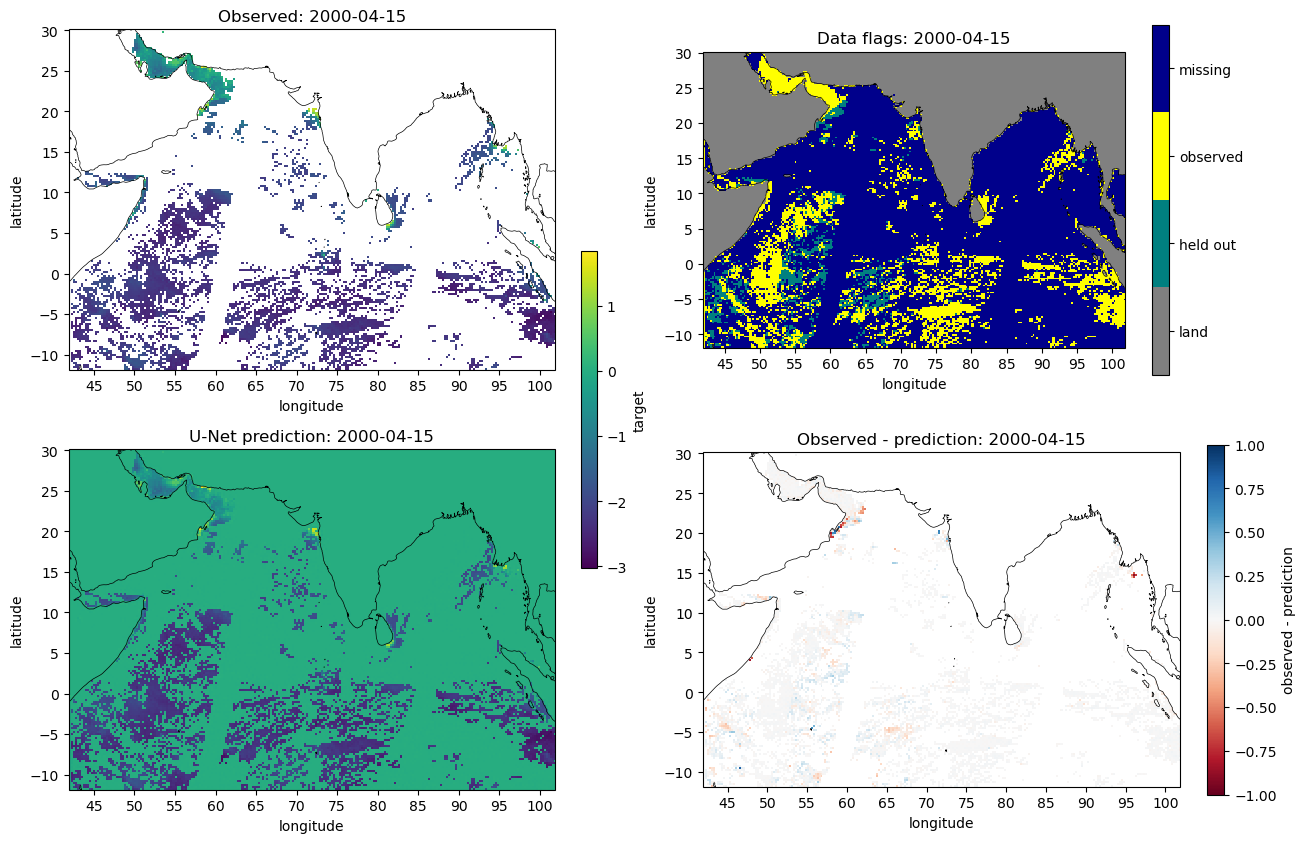

In [5]:
fig, axes = viz.plot_prediction_observed(
    ds_std,
    model,
    metadata,
    date,
    difference_limit=1.0,
)
plt.show()